In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h1 style="text-align: center; color: green;">Temas selectos de Riesgo de Financiero</h1>

### Practica 5 Riesgo de liquidez

<!-- ![image.png](attachment:image.png) -->

<div style="text-align:center">
    <img src="https://finanzasycontabilidad.net/wp-content/uploads/elementor/thumbs/financial-7688471_1280-qef7tak8p5r0gbtcaf6dfp0sl3n0bqsyeewjna7o00.png" width="400">
</div>

El riesgo de liquidez es la posibilidad de que una persona, empresa o institución no pueda cumplir con sus obligaciones financieras a corto plazo o que deba vender activos a un precio menor al de mercado debido a la falta de liquidez. En otras palabras, refleja la dificultad de convertir activos en efectivo sin pérdidas significativas o de disponer de recursos inmediatos para cubrir compromisos.


Algunas definiciones

- __Activo__: Son los recursos económicos que posee una empresa o persona, que generan beneficios futuros.

  - Activos corrientes: Se convierten en efectivo en menos de un año (efectivo, cuentas por cobrar, inventarios).

  - Activos no corrientes: Bienes de largo plazo (propiedades, inversiones a largo plazo).

- __Pasivo__: Son las obligaciones financieras que una entidad debe cumplir, es decir, sus deudas.

  - Pasivos corrientes: Deudas a corto plazo (proveedores, préstamos bancarios menores a un año).

  - Pasivos no corrientes: Compromisos de largo plazo (hipotecas, bonos emitidos).



__Teorema fundamenta de la contabilidad__

$$ \text{Patrimonio neto o capital contable} = Activo - Pasivos$$

__Liquidez__: Es la facilidad con la que un activo puede convertirse en efectivo rápidamente y sin pérdida significativa de valor. El dinero en efectivo es el activo más líquido.

  - Alta liquidez: efectivo, depósitos bancarios.
  - Baja liquidez: bienes raíces, obras de arte.

__Brechas de liquidez__

La brecha de liquidez (Liquidity Gap) mide la diferencia entre:
    $$\text{Brecha}_t = Activos_t - Pasivos_t$$

donde:

$Activos_t$: flujos de efectivo que se recibirán en el periodo t.

$Pasivos_t$:obligaciones que deben pagarse en el periodo t.


Si:

Brecha > 0 → exceso de liquidez

Brecha < 0 → déficit de liquidez


__Ejercicio__

Se tiene el balance de un banco (datos.csv), en el se encuentran los flujos de dinero según su vencimiento, contesta ¿El banco tendrá dinero suficiente para cumplir sus obligaciones en cada plazo?

- Cada fila representa un instrumento financiero del banco.

|Instrumento financiero | Descripción |
|---|---|
|C. Hipotecario | créditos hipotecarios otorgados por el banco|
|C. Automotriz | créditos de autos|
|C. PyME | créditos a empresas pequeñas|
|Bonos | bonos que el banco posee|
|Chequera | depósitos de clientes|
|Préstamos bancarios | deuda que el banco tiene con otros bancos|
|Instrumentos a plazo | depósitos a plazo|

In [49]:
# Leer los datos
df = pd.read_csv(r"D:\Datases_CD\8vo\Riesgos\Practicas\5\datos.csv")
df

,Tipo,Instrumento,Plazo a vencimiento,Tasa,Plazo tasa,Monto MDP
0,Activo,C. Hipotecario,30,Fija,360,200
1,Activo,C. Hipotecario,60,Fija,360,80
2,Activo,C. Hipotecario,90,Fija,360,80
3,Activo,C. Hipotecario,180,Fija,360,70
4,Activo,C. Hipotecario,360,Fija,360,70
5,Activo,C. Automotriz,30,CETES,28,30
6,Activo,C. Automotriz,60,CETES,28,30
7,Activo,C. Automotriz,90,CETES,28,30
8,Activo,C. Automotriz,180,CETES,28,10
9,Activo,C. Automotriz,360,CETES,28,10


#### Brechas de liquidez

In [50]:
# Crear tabla pivote plazo de vencimiento por tipo e instrumento
tabla = pd.pivot_table(
    df,
    values="Monto MDP",
    index=["Tipo", "Instrumento"],
    columns="Plazo a vencimiento",
    aggfunc="sum",
    fill_value=0
)
tabla

Plazo a vencimiento           1     30   60   90   180  360
Tipo    Instrumento                                        
Activo  Bonos                   0     2    0    1    1    0
        C. Automotriz           0    30   30   30   10   10
        C. Empresarial          0     0    0    0  800    0
        C. Hipotecario          0   200   80   80   70   70
        C. Nómina               0     0    0    0    6    6
        C. PyME                 0     0    0  300  300  200
Pasivos Chequera              500  1000    0    0    0    0
        Instrumentos a plazo    0   100    0   50   20   10
        Prestamos Bancarios     0     5    0    5    5    0

In [51]:
# Crear tabla pivote plazo de vencimiento por tipo activo o pasivo
tabla = pd.pivot_table(
    df,
    values="Monto MDP",
    index="Tipo",
    columns="Plazo a vencimiento",
    aggfunc="sum",
    fill_value=0
)
tabla

Plazo a vencimiento,1,30,60,90,180,360
Tipo,,,,,,
Activo,0,232,110,411,1187,286
Pasivos,500,1105,0,55,25,10


In [52]:
# Seleccionar solo activos y pasivos como filas
activos = tabla.loc["Activo"]
pasivos = tabla.loc["Pasivos"]

# Realizar la brecha
brecha = activos - pasivos
brecha

Plazo a vencimiento
1      -500
30     -873
60      110
90      356
180    1162
360     276
dtype: int64

In [53]:
# Realizamos la brecha acumulada
brecha_acum = brecha.cumsum()
brecha_acum

Plazo a vencimiento
1      -500
30    -1373
60    -1263
90     -907
180     255
360     531
dtype: int64

In [54]:
# Unimos los resultados
resultado = pd.DataFrame({
    "Activos": activos,
    "Pasivos": pasivos,
    "Brecha": brecha,
    "Brecha acumulada": brecha_acum
})

resultado

,Activos,Pasivos,Brecha,Brecha acumulada
Plazo a vencimiento,,,,
1,0,500,-500,-500
30,232,1105,-873,-1373
60,110,0,110,-1263
90,411,55,356,-907
180,1187,25,1162,255
360,286,10,276,531


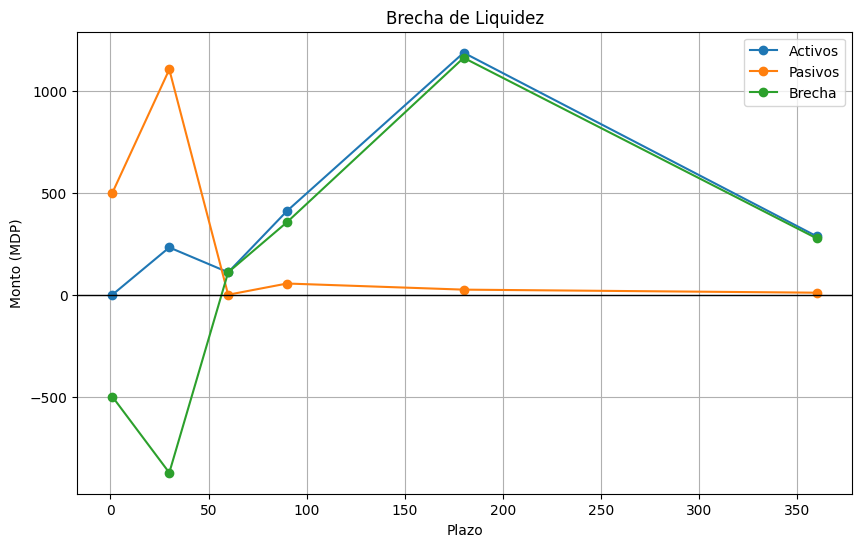

In [55]:
# Realizamos los gráficos de brecha de liquidez
plt.figure(figsize=(10,6))
plt.plot(activos.index, activos.values, marker='o', label='Activos')
plt.plot(pasivos.index, pasivos.values, marker='o', label='Pasivos')
plt.plot(brecha.index, brecha.values, marker='o', label='Brecha')

plt.axhline(0, color='black', linewidth=1)
plt.title("Brecha de Liquidez")
plt.xlabel("Plazo")
plt.ylabel("Monto (MDP)")
plt.legend()
plt.grid(True)
plt.show()

Horizonte de Supervivencia (Métrica de Liquidez)

La fórmula es:$$\text{Horizonte de Supervivencia} = \left( \frac{\text{Activos Líquidos}}{\text{Brecha Acumulada a 30 días}} \right) \times 30$$

¿Qué significa?: Indica cuántos días puede operar la institución financiera usando solo su "efectivo en caja" (Activos Líquidos) para cubrir sus salidas netas de dinero en el primer mes.

In [56]:
# Realizamos el horizonte de supervivencia
activos_liquidos = 500
brecha_30 = brecha_acum.get(30, brecha_acum.get('30'))

if brecha_30 is None or pd.isna(brecha_30) or brecha_30 == 0:
    raise ValueError("No se pudo calcular la brecha acumulada a 30 días. Verifica que exista el plazo de 30 en los datos.")

horizonte = (activos_liquidos / brecha_30) * 30
print(np.ceil(horizonte))

-10.0


- Si ocurre un shock de liquidez, el banco solo podría sobrevivir 11 días.
- Esto es una señal de alerta; significa que la institución se quedaría sin liquidez antes de llegar a la mitad del mes si no consigue nuevas fuentes de fondeo.

Responde:
  
<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
    <li> ¿En qué momento el banco recupera liquidez? </li> 
  </ul>
</div>

En el plazo donde la serie brecha = activos - pasivos cruza de negativo a positivo. Ese es el momento en que los activos vencidos superan a los pasivos vencidos.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
    <li> ¿En qué periodo existe mayor déficit de liquidez? </li> 
  </ul>
</div>

En el plazo con el valor más bajo (más negativo) de brecha. Ese periodo es el que muestra la mayor falta de fondos netos.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
    <li> ¿Qué ocurre con la brecha acumulada? </li> 
  </ul>
</div>

La brecha acumulada `brecha_acum = brecha.cumsum()` muestra el resultado neto acumulado a lo largo de los plazos. Si sigue negativa, el déficit se está acumulando; si sube hacia positivo, el banco mejora su posición global de liquidez.

In [63]:
max_deficit_period = brecha.idxmin()
max_deficit_amount = brecha.min()

print("Periodo con mayor déficit de liquidez:", max_deficit_period)
print("Monto de déficit:", max_deficit_amount)

print("\nBrecha acumulada por plazo:")
print(brecha_acum)

if (brecha_acum < 0).all():
    print("\nLa brecha acumulada se mantiene negativa en todos los plazos: el déficit neto se acumula.")
elif (brecha_acum >= 0).any():
    first_positive = brecha_acum[brecha_acum >= 0].index[0]
    print(f"\nLa brecha acumulada llega a cero o positivo a partir del plazo {first_positive}.")
else:
    print("\nLa brecha acumulada aún no llega a cero o positivo en los plazos disponibles.")

Periodo con mayor déficit de liquidez: 90
Monto de déficit: -42

Brecha acumulada por plazo:
Plazo tasa
28     107
90      65
160     45
180     41
360    531
dtype: int64

La brecha acumulada llega a cero o positivo a partir del plazo 28.


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
    <li> ¿Qué estrategia podría utilizar el banco para cubrir una brecha negativa? </li>    
  </ul>
</div>

- Obtener financiamiento a corto plazo o líneas de crédito.
- Aumentar activos líquidos (efectivo, depósitos disponibles).
- Refinanciar pasivos vencidos o alargar plazos.
- Vender activos líquidos o no estratégicos.
- Ajustar la estructura de cartera para reducir la salida de efectivo inmediata.

### Brecha de Reprecio

In [57]:
# Crear tabla pivote plazo de tasa por tipo e instrumento
tabla = pd.pivot_table(
    df,
    values="Monto MDP",
    index=["Tipo", "Instrumento"],
    columns="Plazo tasa",
    aggfunc="sum",
    fill_value=0
)
tabla

Plazo tasa                     28   90   160  180  360
Tipo    Instrumento                                   
Activo  Bonos                    2    1    0    1    0
        C. Automotriz          110    0    0    0    0
        C. Empresarial         800    0    0    0    0
        C. Hipotecario           0    0    0    0  500
        C. Nómina                0   12    0    0    0
        C. PyME                800    0    0    0    0
Pasivos Chequera              1500    0    0    0    0
        Instrumentos a plazo   100   50   20    0   10
        Prestamos Bancarios      5    5    0    5    0

Esto importa porque si las tasas suben o bajan, los ingresos del banco cambian.

In [58]:
# Crear tabla pivote plazo de tasa por tipo de activo o pasivo

tabla = pd.pivot_table(
    df,
    values="Monto MDP",
    index="Tipo",
    columns="Plazo tasa",
    aggfunc="sum",
    fill_value=0
)
tabla

Plazo tasa,28,90,160,180,360
Tipo,,,,,
Activo,1712,13,0,1,500
Pasivos,1605,55,20,5,10


In [59]:
# Obtenemos las filas de activo y pasivo
activos = tabla.loc["Activo"]
pasivos = tabla.loc["Pasivos"]

# Realizamos la brecha de repricing
brecha = activos - pasivos
brecha

Plazo tasa
28     107
90     -42
160    -20
180     -4
360    490
dtype: int64

In [60]:
# La suma acumulada de la brecha
brecha_acum = brecha.cumsum()
brecha_acum

Plazo tasa
28     107
90      65
160     45
180     41
360    531
dtype: int64

In [61]:
# Unimos los resultados
resultado = pd.DataFrame({
    "Activos": activos,
    "Pasivos": pasivos,
    "Brecha": brecha,
    "Brecha acumulada": brecha_acum
})

resultado

,Activos,Pasivos,Brecha,Brecha acumulada
Plazo tasa,,,,
28,1712,1605,107,107
90,13,55,-42,65
160,0,20,-20,45
180,1,5,-4,41
360,500,10,490,531


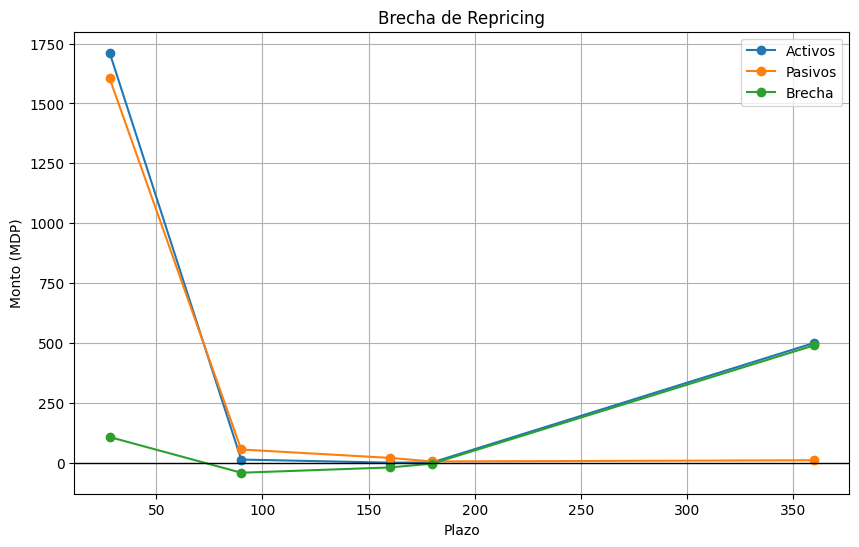

In [62]:
plt.figure(figsize=(10,6))
plt.plot(activos.index, activos.values, marker='o', label='Activos')
plt.plot(pasivos.index, pasivos.values, marker='o', label='Pasivos')
plt.plot(brecha.index, brecha.values, marker='o', label='Brecha')

plt.axhline(0, color='black', linewidth=1)
plt.title("Brecha de Repricing")
plt.xlabel("Plazo")
plt.ylabel("Monto (MDP)")
plt.legend()
plt.grid(True)
plt.show()

Responde
<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
    <li> Si el Banco Central sube la tasa de referencia mañana, ¿en qué periodos (28, 90, 160 o 180) se vería beneficiada la institución y en cuáles se vería perjudicada?</li>
  </ul>
</div>



Beneficiada en los periodos donde la brecha de repricing es positiva: eso significa que los activos reprecian más rápido o en mayor monto que los pasivos.
Perjudicada en los periodos donde la brecha es negativa: ahí los pasivos devengan tasa antes o en mayor monto que los activos.

In [64]:
periodos = [28, 90, 160, 180]
for periodo in periodos:
    if periodo in brecha.index:
        valor = brecha.loc[periodo]
        estado = "beneficiada" if valor > 0 else "perjudicada" if valor < 0 else "neutra"
        print(f"Periodo {periodo}: brecha = {valor:.2f} → {estado}")
    else:
        print(f"Periodo {periodo}: no existe en los datos de repricing")

Periodo 28: brecha = 107.00 → beneficiada
Periodo 90: brecha = -42.00 → perjudicada
Periodo 160: brecha = -20.00 → perjudicada
Periodo 180: brecha = -4.00 → perjudicada


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
<li> Observando la Brecha Acumulada al día 180, ¿la institución es más vulnerable a una subida o a una bajada de tasas en el corto plazo?</li>
  </ul>
</div>

In [65]:
dia_180 = 180
if dia_180 in brecha_acum.index:
    valor_acum = brecha_acum.loc[dia_180]
    if valor_acum > 0:
        print(f"\nBrecha acumulada en {dia_180}: {valor_acum:.2f} → la institución es más vulnerable a una bajada de tasas en el corto plazo.")
    elif valor_acum < 0:
        print(f"\nBrecha acumulada en {dia_180}: {valor_acum:.2f} → la institución es más vulnerable a una subida de tasas en el corto plazo.")
    else:
        print(f"\nBrecha acumulada en {dia_180}: {valor_acum:.2f} → posición neutra al día {dia_180}.")
else:
    print(f"\nBrecha acumulada al día {dia_180}: no existe en los datos")



Brecha acumulada en 180: 41.00 → la institución es más vulnerable a una bajada de tasas en el corto plazo.


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
<li> El "Salto" del Día 360: "¿Qué tipo de instrumentos financieros podrían generar esa brecha tan grande al año? (Ejemplo: Créditos hipotecarios)</li>
  </ul>
</div>

- Instrumentos a largo plazo como créditos hipotecarios
- Bonos de largo plazo
- Préstamos corporativos o créditos de largo plazo
- Depósitos e inversiones estructuradas que vencen al año

Estos generan un salto porque tienen vencimientos o repricing muy alejados en el tiempo.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  <ul>
<li> Si el mercado entrara en una crisis de liquidez donde nadie quisiera prestar a largo plazo (día 360) cómo se vería la brecha acumulada.</li>
  </ul>
</div>

La brecha acumulada se desplomaría o se volvería mucho más negativa en el tramo largo.
El déficit neto se acumularía, mostrando que el banco no puede reemplazar ni financiar los vencimientos largos y su posición de liquidez empeora

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Investiga y escribe qué sucedió con Silicon Valley Bank relacionado con el riesgo de liquidez. Explica cómo este riesgo afectó a la institución y cuáles fueron las consecuencias principales.
</div>

Silicon Valley Bank cayó por una mezcla muy peligrosa: tenía muchos depósitos de empresas tecnológicas, gran parte no asegurados, y una parte importante de ese dinero la había invertido en bonos de largo plazo. Cuando subieron las tasas de interés, esos bonos perdieron valor de mercado. Al mismo tiempo, sus clientes empezaron a retirar dinero más rápido, así que el banco tuvo que vender activos con pérdidas para conseguir efectivo. Ahí el problema dejó de ser solo “contable” y se volvió un problema real de liquidez: no tenía dinero disponible suficiente para responder a los retiros.

El riesgo de liquidez fue el corazón del problema. SVB dependía mucho de una base de depositantes muy concentrada y sensible al miedo. Cuando anunció pérdidas y un intento de levantar capital, eso asustó al mercado y a sus clientes, y se desató una corrida bancaria muy rápida. Según la revisión de la Reserva Federal, el banco incluso falló sus propias pruebas internas de liquidez y no tenía planes viables para obtener efectivo en un momento de estrés.

La consecuencia principal fue que el banco ya no pudo cumplir con las solicitudes de retiro y fue cerrado por los reguladores el 10 de marzo de 2023. Después, las autoridades de Estados Unidos intervinieron para proteger a todos los depositantes de SVB y contener el contagio al resto del sistema bancario. La FDIC estimó pérdidas relevantes para su fondo de seguro, y el episodio provocó nerviosismo en todo el sector bancario regional.